- Ideia inicial é fazer uma análise exploratória dos dados, identificar

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import io #capturar apenas a saida

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df = pd.read_csv('/content/drive/MyDrive/Spotfy/Spotify Most Streamed Songs.csv')

In [ ]:
df.head(10)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125,B,Major,80,89,83,31,0,8,4,Not Found
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92,C#,Major,71,61,74,7,0,10,4,https://i.scdn.co/image/ab67616d0000b2730656d5...
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138,F,Major,51,32,53,17,0,31,6,https://i.scdn.co/image/ab67616d0000b273e85259...
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170,A,Major,55,58,72,11,0,11,15,https://i.scdn.co/image/ab67616d0000b273e787cf...
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144,A,Minor,65,23,80,14,63,11,6,https://i.scdn.co/image/ab67616d0000b273ab5c9c...
5,Sprinter,"Dave, Central Cee",2,2023,6,1,2186,91,183706234,67,213,88,17,946,141,C#,Major,92,66,58,19,0,8,24,https://i.scdn.co/image/ab67616d0000b273e3a09a...
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,34,222,43,13,418,148,F,Minor,67,83,76,48,0,8,3,https://i.scdn.co/image/ab67616d0000b2732071a0...
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,25,89,30,13,194,100,F,Major,67,26,71,37,0,11,4,https://i.scdn.co/image/ab67616d0000b273a00a81...
8,fukumean,Gunna,1,2023,5,15,1096,83,95217315,60,210,48,11,953,130,C#,Minor,85,22,62,12,0,28,9,https://i.scdn.co/image/ab67616d0000b273017d5e...
9,La Bebe - Remix,"Peso Pluma, Yng Lvcas",2,2023,3,17,2953,44,553634067,49,110,66,13,339,170,D,Minor,81,56,48,21,0,8,33,Not Found


In [ ]:

buffer = io.StringIO()
df.info(buf=buffer)


summary = pd.DataFrame({
    "Informação": df.dtypes,
    "Cardinalidade": df.nunique(),
    "Valores não nulos": df.notnull().sum(),
    "Dados Nulos": df.isnull().sum()
    })

print(summary)

                     Informação  Cardinalidade  Valores não nulos  Dados Nulos
track_name               object            943                953            0
artist(s)_name           object            645                953            0
artist_count              int64              8                953            0
released_year             int64             50                953            0
released_month            int64             12                953            0
released_day              int64             31                953            0
in_spotify_playlists      int64            879                953            0
in_spotify_charts         int64             82                953            0
streams                  object            949                953            0
in_apple_playlists        int64            234                953            0
in_apple_charts           int64            172                953            0
in_deezer_playlists      object            348      

### Informações básicas:

- **track_name:** Nome do som.
- **artist(s)_name:** Nome do artista(s).
- **artist_count:** Number of artists contributing to the song.
- **released_year, released_month, released_day:** Detalhes da data de lançamento.

### Métricas de streaming:

- **in_spotify_playlists:** Número de playlists do Spotify em que a música aparece.
- **in_spotify_charts:** Classificação da música nas paradas do Spotify.
- **streams:** Número total de transmissões no Spotify.
- **in_apple_playlists, in_apple_charts:** Presença em playlists e paradas do Apple Music.
- **in_deezer_playlists, in_deezer_charts:** Presença em playlists e paradas do Deezer.
- **in_shazam_charts:** Classifique nas paradas do Shazam.

### Musical Attributes

- **bpm:** Batidas por minuto, representando o ritmo (tempo) da música.
- **key:** Tom da música.
- **mode:** Indica se a música está em modo maior ou menor.
- **danceability_%:** Adequação da música para dançar.
- **valence_%:** Positividade do conteúdo musical da canção.
- **energy_%:** Nível de energia percebido na música.
- **acousticness_%:** Presença de sons acústicos na canção.
- **instrumentalness_%:** Proporção de conteúdo instrumental na faixa.
- **liveness_%:** Presença de elementos de performance ao vivo.
- **speechiness_%:** Quantidade de palavras faladas na música.

In [ ]:
# 'in_deezer_playlist esta inicialmente em OBJECT
# As colunas 'released_year', 'released_month' e 'released_day' estão fora da formatação de data
df['in_deezer_playlists'] = pd.to_numeric(df['in_deezer_playlists'], errors= 'coerce').fillna(0).astype(int)
df['in_deezer_charts'] = pd.to_numeric(df['in_deezer_charts'], errors= 'coerce').fillna(0).astype(int)
df['in_shazam_charts'] = pd.to_numeric(df['in_shazam_charts'], errors= 'coerce')
#df['streams'] = pd.to_numeric(df['streams'].astype(int))

df['released_date'] = pd.to_datetime(df['released_year'].astype(str)+ '-' +
                                     df['released_month'].astype(str)+ '-' +
                                     df['released_day'].astype(str))

#União colunas str
df['ref_anomes'] = df['released_date'].dt.strftime('%d-%Y')





In [ ]:
# df['streams'] = pd.to_numeric(df['streams'].astype(int)) investigação
print(f"Valores totais colunas 'streams': {df['streams'].unique()}")
#Aparentemente existe um valor estranho entre as cedulas (BPM110KeyAModeMajorDanceability53...) que esta impedindo a transformação de todas as colunas em INT



Valores totais colunas 'streams': ['141381703' '133716286' '140003974' '800840817' '303236322' '183706234'
 '725980112' '58149378' '95217315' '553634067' '505671438' '58255150'
 '1316855716' '387570742' '2513188493' '1163093654' '496795686' '30546883'
 '335222234' '363369738' '86444842' '52135248' '1297026226' '200647221'
 '115364561' '78300654' '899183384' '61245289' '429829812' '127408954'
 '22581161' '52294266' '843957510' '999748277' '618990393' '123122413'
 '188933502' '1355959075' '786181836' '176553476' '354495408' '2808096550'
 '1109433169' '1047101291' '65156199' '570515054' '1085685420'
 '1647990401' '2565529693' '518745108' '107753850' '177740666' '153372011'
 '57876440' '1813673666' '3703895074' '256483385' '1214083358' '16011326'
 '812019557' '111947664' '156338624' '720434240' '357925728' '674072710'
 '1755214421' '404562836' '373199958' '14780425' '39578178' '54266102'
 '2557975762' '751134527' '2282771485' '1356565093' '1592909789'
 '635412045' '1230675890' '585695368' 

In [ ]:
df['streams'] = df['streams'].replace('BPM110KeyAModeMajorDanceability53Valence75Energy69Acousticness7Instrumentalness0Liveness17Speechiness3', '0')
#O valor esta na linha 574, é possível observar que todos os outros valores desta linha estão integros
#A partir disso vamos substituir este valor pela média de todos os valores existentes nessa coluna

df['streams'] = df['streams'].replace('BPM110KeyAModeMajorDanceability53Valence75Energy69Acousticness7Instrumentalness0Liveness17Speechiness3', '0')
df['streams'] = df['streams'].astype(int)
df.mean_streams = df['streams'].mean()
df['streams'] = df['streams'].replace(0, df.mean_streams)


Após verificar a que o streams possui um valor estranho, por curiosidade também verifiquei as colunas in_deezer_charts, in_shazam_charts. Após a analise, concluo que todas estão OK.

In [ ]:
print(f"Colunas distintas em 'in_deezer_charts': {df['in_deezer_charts'].nunique()}")
print(f"Colunas unicas em 'in_deezer_charts': {df['in_deezer_charts'].unique()}")


Colunas distintas em 'in_deezer_charts': 34
Colunas unicas em 'in_deezer_charts': [10 14 12 15 17 13 11  5 58 24 46  6  2  4  1 38  8 23  9 18  7  3 45 16
 37  0 19 20 28 26 31 22 29 21]


In [ ]:
print(f"Colunas distintas em 'in_shazam_charts': {df['in_shazam_charts'].nunique()}")
print(f"Colunas únicas em 'in_shazam_charts': {df['in_shazam_charts'].unique()}")


Colunas distintas em 'in_shazam_charts': 191
Colunas únicas em 'in_shazam_charts': [826. 382. 949. 548. 425. 946. 418. 194. 953. 339. 251. 168.  nan 187.
   0.  29. 150.  73. 139.  96. 211. 325. 294. 197.  27. 310. 354. 184.
 212.  81.  82. 100.  62.  69. 727. 311. 102. 332. 259. 140.  16. 110.
 810. 176. 615. 210. 216. 215. 167.  37. 171. 272. 529.  26.   5. 169.
 230.  84. 154.  93. 115.  72.   8. 323.  49. 429. 162.  10. 478. 236.
 200.  78. 266. 486. 204.  34. 202. 312.  32. 153. 519. 458.  48. 666.
  14. 925.  88. 203.  44.  74. 638.  64.  71.   2.   3. 136. 148.  22.
 368.   1. 189.  52.   9.  31.  66. 208.  28. 558. 195.  13.  60. 503.
  56.  15. 454.  40. 285. 129.  58. 117.  47.  20.  30.  80. 263. 116.
  57.  39. 111.   7. 166.  19.  99.  51. 109.  42.  33. 675. 348.  36.
 240. 113.   6.  23.   4. 182.  54. 438.  11.  17.  50. 320.  55.  18.
  38.  43. 105.  24.  63. 444.  85.  21. 165. 103. 734.  61. 221.  59.
 451.  41. 192. 124.  25.  35.  46.  12.  75.  45.  77. 160. 120.

In [ ]:
print(f"Colunas distintas em 'in_apple_charts': {df['in_apple_charts'].nunique()}")
print(f"Colunas unicas em 'in_apple_charts': {df['in_apple_charts'].unique()}")


Colunas distintas em 'in_apple_charts': 172
Colunas unicas em 'in_apple_charts': [263 126 207 133 213 222  89 210 110 205 202 215 156 198 162 212 227 100
 104 163 119  98 152 182 149 109 107   0 135 185 142 123  33 108 111 159
 117 184  58 145  48 127  21 137  86  64  71 122 199  79 115 112  17  84
 121   2  55  32  93  80 144  87  65  85  74  16  96   6  72  99  75 125
 120 148  52  97  76  45 105 143 106  91 166  40 113 102  23  81  12 116
  69  44  59 124  37  90  88   9  29   8  14  38 181  95 101  82  60  92
  70  20  25  10  68  73 129  50   3  46  18  15  41  34  77  78  66  26
  43  57  27  53  22  42  13   7   5 103   4   1  31  35  54  51  11  19
  94  24  56  47 132 168  63  30  39  36 172  61  49  28 130 167 118 155
 134  67 114 160 188 136 151 275 266 141]


### Fato passivel de investigação:
o número de reprodução de cada música tende a ser diferente, dificilmente vamos ver duas músicas tendo exatamente o mesmo número de reproduções. Como observado, existem 8 músicas com os exatos mesmo número de streams.

In [ ]:
print(f"Quantidade de aparições de cada valor da variável 'streams': {df['streams'].value_counts()}")

Quantidade de aparições de cada valor da variável 'streams': streams
7.238945e+08    2
1.223481e+09    2
3.955914e+08    2
1.563386e+08    2
2.009727e+08    1
7.101497e+07    1
5.602228e+08    1
1.806618e+09    1
7.733777e+07    1
5.285447e+08    1
8.656401e+08    1
9.913361e+08    1
2.159347e+09    1
2.113725e+08    1
6.517329e+08    1
6.083340e+08    1
8.637566e+08    1
7.974023e+08    1
1.695712e+09    1
1.759568e+09    1
2.233199e+08    1
5.493799e+07    1
2.268976e+08    1
2.583160e+08    1
5.961521e+08    1
1.771299e+08    1
7.165915e+08    1
1.210599e+09    1
2.463767e+08    1
4.963114e+08    1
1.467894e+08    1
5.939176e+08    1
7.837066e+08    1
4.226911e+08    1
1.062346e+09    1
1.252564e+09    1
8.510705e+08    1
2.638945e+08    1
3.459036e+08    1
9.516376e+08    1
9.568653e+08    1
4.274860e+08    1
1.566584e+08    1
6.245155e+08    1
7.777654e+08    1
1.690193e+09    1
1.138474e+09    1
3.552192e+08    1
2.902286e+08    1
1.062957e+09    1
1.180095e+09    1
1.456081e+09 

### Conclusão:
Após avaliar as músicas de que possuem seu número de reprodução repetida é possível verificar que são músicas iguais que apresentam diferenças como datas de lançamento, nome diferente, cantor diferente.

In [ ]:
valores = [723894473, 1223481149, 395591396, 156338624]

df_filtrado = df[df['streams'].isin(valores)]
df_filtrado.head()


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url,released_date,ref_anomes
61,Boy's a liar Pt. 2,"PinkPantheress, Ice Spice",2,2023,2,3,5184,41,1.563386e+08,154,84,102,14,37.0,133,F,Major,70,86,81,25,0,25,5,https://i.scdn.co/image/ab67616d0000b27342c5ba...,2023-02-03,03-2023
365,Enemy (with JID) - from the series Arcane Leag...,"Imagine Dragons, League of Legends, JID, Arcane",4,2021,9,3,6180,7,1.223481e+09,122,88,580,21,10.0,77,B,Minor,72,59,76,24,0,42,28,https://i.scdn.co/image/ab67616d0000b273fc915b...,2021-09-03,03-2021
372,About Damn Time,Lizzo,1,2022,7,15,2332,2,7.238945e+08,0,0,25,0,0.0,109,A#,Minor,84,72,74,10,0,34,7,https://i.scdn.co/image/ab67616d0000b273b817e7...,2022-07-15,15-2022
384,Boy's a liar,PinkPantheress,1,2022,11,30,1225,0,1.563386e+08,27,0,28,13,0.0,133,F,Major,66,74,84,25,0,21,4,https://i.scdn.co/image/ab67616d0000b27342c5ba...,2022-11-30,30-2022
459,A Holly Jolly Christmas - Single Version,Burl Ives,1,1952,1,1,7930,0,3.955914e+08,108,120,73,0,0.0,140,NaN,Major,67,81,36,64,0,15,3,https://i.scdn.co/image/ab67616d0000b273b9b921...,1952-01-01,01-1952


###Correção Valores Nulos

Algumas colunas apresentam valores nulos, então é necessario entender o porque isso acontece:
- Os valores nulos estão em colunas que apresentam informações relevantes em toda sua linha, portanto exlcuir não torna uma opção segura
- Um das opções é substituir pela médiao e moda, mas como o valores nulos da variável 'in_shazam_charts' alcaçam 6% dos totais, enquanto a variavel 'key' chega a 10%, portanto, essa substituição pode enviesar futuros modelos que utilizem essa base de dado limpa.
- Nas colunas  'in_shazam_charts' a melhor opção seria a substituição por um valor discrepante de '9999' no qual, se destacara quando aparecer em alguma analise futura demonstrando a existencia dos valores nulos.
- Na coluna KEY substituiremos por 'miss_verificar' para demonstrar em futuras analises que este valor é nulo

In [ ]:
#Variavel 'in_shazam_charts'
df[df['in_shazam_charts'].isnull()].head(10)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url,released_date,ref_anomes
12,Flowers,Miley Cyrus,1,2023,1,12,12211,115,1.316856e+09,300,215,745,58,NaN,118,NaN,Major,71,65,68,6,0,3,7,https://i.scdn.co/image/ab67616d0000b27358039b...,2023-01-12,12-2023
13,Daylight,David Kushner,1,2023,4,14,3528,98,3.875707e+08,80,156,182,24,NaN,130,D,Minor,51,32,43,83,0,9,3,https://i.scdn.co/image/ab67616d0000b27395ca6a...,2023-04-14,14-2023
14,As It Was,Harry Styles,1,2022,3,31,23575,130,2.513188e+09,403,198,863,46,NaN,174,F#,Minor,52,66,73,34,0,31,6,https://i.scdn.co/image/ab67616d0000b2732e8ed7...,2022-03-31,31-2022
17,What Was I Made For? [From The Motion Picture ...,Billie Eilish,1,2023,7,13,873,104,3.054688e+07,80,227,95,24,NaN,78,NaN,Major,44,14,9,96,0,10,3,Not Found,2023-07-13,13-2023
24,Popular (with Playboi Carti & Madonna) - The I...,"The Weeknd, Madonna, Playboi Carti",3,2023,6,2,1945,87,1.153646e+08,74,182,87,14,NaN,99,C#,Major,85,83,68,7,0,36,20,https://i.scdn.co/image/ab67616d0000b2734c8f09...,2023-06-02,02-2023
44,Barbie World (with Aqua) [From Barbie The Album],"Nicki Minaj, Aqua, Ice Spice",3,2023,6,23,1117,80,6.515620e+07,82,145,65,16,NaN,144,NaN,Major,77,75,58,52,0,23,25,https://i.scdn.co/image/ab67616d0000b2737e8f93...,2023-06-23,23-2023
54,Another Love,Tom Odell,1,2012,10,15,18371,83,1.813674e+09,250,122,0,19,NaN,123,E,Minor,45,13,54,70,0,9,4,https://i.scdn.co/image/ab67616d0000b2731917a0...,2012-10-15,15-2012
55,Blinding Lights,The Weeknd,1,2019,11,29,43899,69,3.703895e+09,672,199,0,20,NaN,171,C#,Major,50,38,80,0,0,9,7,https://i.scdn.co/image/ab67616d0000b2738863bc...,2019-11-29,29-2019
71,Heat Waves,Glass Animals,1,2020,6,28,22543,63,2.557976e+09,386,144,707,28,NaN,81,B,Major,76,53,53,44,0,9,9,https://i.scdn.co/image/ab67616d0000b273712701...,2020-06-28,28-2020
73,Sweater Weather,The Neighbourhood,1,2012,5,14,16413,61,2.282771e+09,166,87,0,1,NaN,124,A#,Major,61,41,81,5,2,10,3,https://i.scdn.co/image/ab67616d0000b2738265a7...,2012-05-14,14-2012


In [ ]:
df['in_shazam_charts'] = df['in_shazam_charts'].fillna(9999)
df['in_shazam_charts'] = df['in_shazam_charts'].astype(int)
df['in_shazam_charts'].isnull().sum()

np.int64(0)

In [ ]:
#Variavel 'key'
print(f"Colunas distintas em 'key': {df['key'].nunique()}")
print(f"Colunas unicas em 'key': {df['key'].unique()}")

Colunas distintas em 'key': 11
Colunas unicas em 'key': ['B' 'C#' 'F' 'A' 'D' 'F#' nan 'G#' 'G' 'E' 'A#' 'D#']


In [ ]:
df[df['key'].isnull()].head(5)


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url,released_date,ref_anomes
12,Flowers,Miley Cyrus,1,2023,1,12,12211,115,1.316856e+09,300,215,745,58,9999,118,NaN,Major,71,65,68,6,0,3,7,https://i.scdn.co/image/ab67616d0000b27358039b...,2023-01-12,12-2023
17,What Was I Made For? [From The Motion Picture ...,Billie Eilish,1,2023,7,13,873,104,3.054688e+07,80,227,95,24,9999,78,NaN,Major,44,14,9,96,0,10,3,Not Found,2023-07-13,13-2023
22,I Wanna Be Yours,Arctic Monkeys,1,2013,1,1,12859,110,1.297026e+09,24,98,582,2,73,135,NaN,Minor,48,44,42,12,2,11,3,https://i.scdn.co/image/ab67616d0000b2734ae1c4...,2013-01-01,01-2013
35,Los del Espacio,"Big One, Duki, Lit Killah, Maria Becerra, FMK,...",8,2023,6,1,1150,31,1.231224e+08,22,33,34,7,184,120,NaN,Major,81,63,68,11,0,11,4,Not Found,2023-06-01,01-2023
44,Barbie World (with Aqua) [From Barbie The Album],"Nicki Minaj, Aqua, Ice Spice",3,2023,6,23,1117,80,6.515620e+07,82,145,65,16,9999,144,NaN,Major,77,75,58,52,0,23,25,https://i.scdn.co/image/ab67616d0000b2737e8f93...,2023-06-23,23-2023


In [ ]:
df['key'] = df['key'].fillna('Miss_verificar')
df['key'].isnull().sum()

np.int64(0)

###Verificando se o tratamento inicial esta concluido
- Coluna informção esta com todas as variaveis corrigidas
- Nenhuma coluna apresenta mais valores nulos


In [ ]:
buffer = io.StringIO()
df.info(buf=buffer)


summary = pd.DataFrame({
    "Informação": df.dtypes,
    "Cardinalidade": df.nunique(),
    "Valores não nulos": df.notnull().sum(),
    "Dados Nulos": df.isnull().sum()
    })

print(summary)

                          Informação  Cardinalidade  Valores não nulos  \
track_name                    object            943                953   
artist(s)_name                object            645                953   
artist_count                   int64              8                953   
released_year                  int64             50                953   
released_month                 int64             12                953   
released_day                   int64             31                953   
in_spotify_playlists           int64            879                953   
in_spotify_charts              int64             82                953   
streams                      float64            949                953   
in_apple_playlists             int64            234                953   
in_apple_charts                int64            172                953   
in_deezer_playlists            int64            272                953   
in_deezer_charts               int64  

##Analise estatistica


- **artist_count**: É possivel verificar que a maior parte dos artistas (75%) tem preferencia por cantar solo
  - No entando o máximo de artista que uma música contem é 8, essa é uma observação importante pois pode indicar outliers em analise futuras


- **Streams:**: O número de streams médio é de 513 milhões, no entanto existem músicas que estão muito a baixo com apenas 2762 streams. Isso demonstra uma alta dispersão na quantidade de reprodução de músicas.



-  **released_year**: A maior parte das músicas mais tocadas no Spotify foi lançada a partir de 2020. Esse padrão sugere que o consumo musical está fortemente concentrado em lançamentos recentes, indicando uma renovação constante das preferências do público.

- **Danceability, Energy, Valence, BPM**:
  - **BPM médio:** Em média as musicas que fazem mais sucesso apresentam um ritimo levemente acelerado (122BPM).
  - **Danceability média:** 67%  das músicas apresentam alto potencial para dança.
  - **Energy média:** 64% das músicas exibem alta intensidade sonora.








In [ ]:
df.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,released_date
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,9.530000e+02,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,5.141369e+08,67.812172,51.908709,100.643232,2.666317,646.166842,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165,2018-09-10 05:09:45.519412480
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,2.762000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000,1930-01-01 00:00:00
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,1.417210e+08,13.000000,7.000000,9.000000,0.000000,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000,2020-06-28 00:00:00
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,2.908332e+08,34.000000,38.000000,31.000000,0.000000,4.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000,2022-04-08 00:00:00
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,6.738011e+08,88.000000,87.000000,100.000000,2.000000,54.000000,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000,2022-11-04 00:00:00
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,3.703895e+09,672.000000,275.000000,974.000000,58.000000,9999.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000,2023-07-14 00:00:00
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,5.665592e+08,86.441493,50.630241,173.887239,6.035599,2363.415657,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888,NaN


##Insigts
  ### Média de presença em playlist por plataforma
- Podemos observar que o spotify é uma vitrine para os artistas, as músicas estão presentes nas playlits em maior quantidade nessa plataforma em relação as outras
  - Olhando pelo lado do artista é uma boa oportunidade a inclusão de seus singles nessa plataforma para alavancar sua composição
  ### Relação total de playlist x streams
- Há uma evidente correlação entre o numero de playlists que a música se encontra em relação a quantidade de streams que ela possui
  - Esse achado pode orientar decisões de investimento em curadoria de playlists e parcerias com criadores de conteúdo musical, buscando maximizar o retorno de streams
  ### Distribuição de lançamentos por Mês
- A concentração de lançamentos ocorre principalmente entre abril e maio. Quando pesquisado mais a fundo, observa-se que este período marca o início do verão no hemisfério norte, uma das épocas de maior consumo de música devido ao aumento de eventos ao ar livre, festivais e atividades sociais.
  - Por outro lado, meses como agosto e setembro apresentam queda no número de lançamentos, o que pode representar uma janela de oportunidade competitiva para novos artistas ou gravadoras buscarem maior destaque com menor saturação do mercado.

/tmp/ipython-input-385563498.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


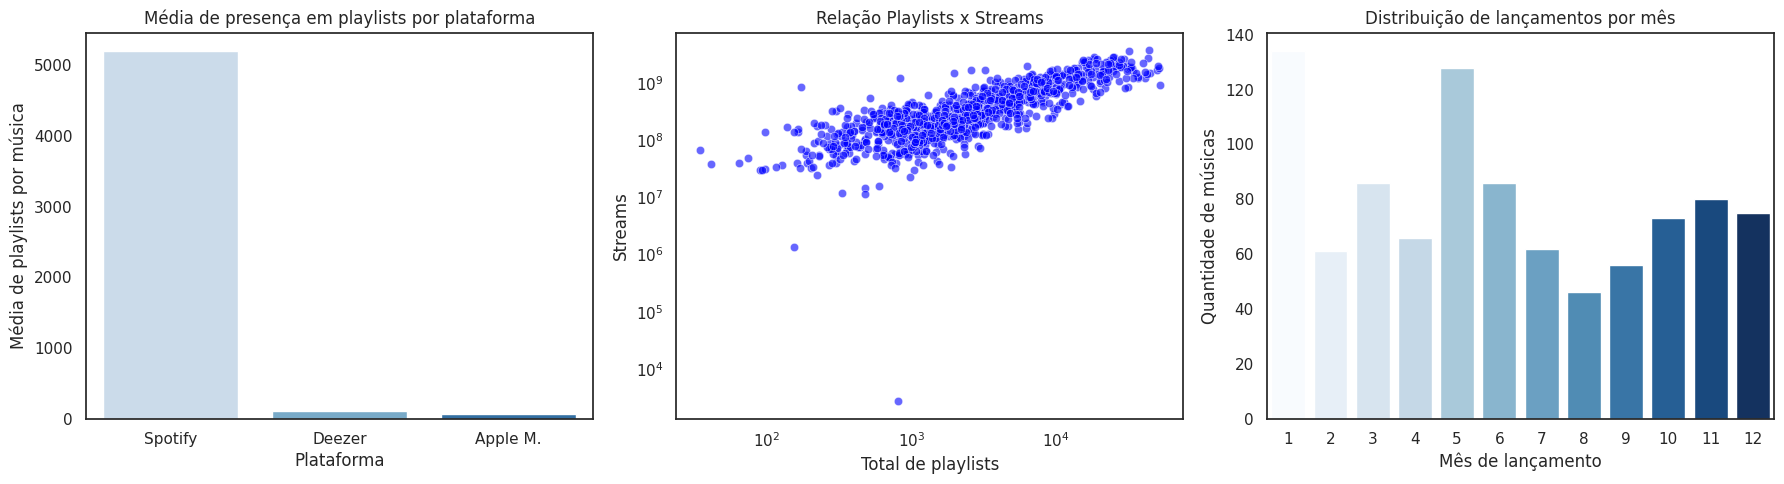

In [ ]:
sns.set_style("white")

# --- Gráfico 1: Média de presenças em playlist por plataforma ---
plataformas = {
    'in_spotify_playlists': 'Spotify',
    'in_apple_playlists': 'Apple M.',
    'in_deezer_playlists': 'Deezer'
}
media_plataformas = df[list(plataformas.keys())].mean().rename(index=plataformas).sort_values(ascending=False)

# Produção da variavel
df['total_playlists'] = df[['in_spotify_playlists', 'in_apple_playlists', 'in_deezer_playlists']].sum(axis=1)

# Criação da figura
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(
    x=media_plataformas.index,
    y=media_plataformas.values,
    palette='Blues',
    ax=axes[0]
)
axes[0].set_title("Média de presença em playlists por plataforma")
axes[0].set_xlabel("Plataforma")
axes[0].set_ylabel("Média de playlists por música")
axes[0].grid(False)

# --- Gráfico 2: Relação total de playlists x streams ---
sns.scatterplot(
    x='total_playlists',
    y='streams',
    data=df,
    alpha=0.6,
    color='blue',
    ax=axes[1]
)
axes[1].set_title("Relação Playlists x Streams")
axes[1].set_xlabel("Total de playlists")
axes[1].set_ylabel("Streams")
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(False)

# --- Gráfico 3: Distribuição de lançamentos por mês ---
sns.countplot(
    x='released_month',
    data=df,
    hue='released_month',
    palette='Blues',
    legend=False,
    ax=axes[2]
)
axes[2].set_title("Distribuição de lançamentos por mês")
axes[2].set_xlabel("Mês de lançamento")
axes[2].set_ylabel("Quantidade de músicas")
axes[2].grid(False)


plt.tight_layout()
plt.show()


###Correlação entre características musicais
- As correlações são baixas, o que sugere que nenhum atributo isolado explica sozinho o sucesso de uma música.
- Ainda assim, um ponto chamou atenção: a correlação negativa de -0.58 entre “energy_%” e “acousticness_%”, pode até ser obvio, mas é interessante pensa quer músicas mais energéticas tendem a ter produções acústicas

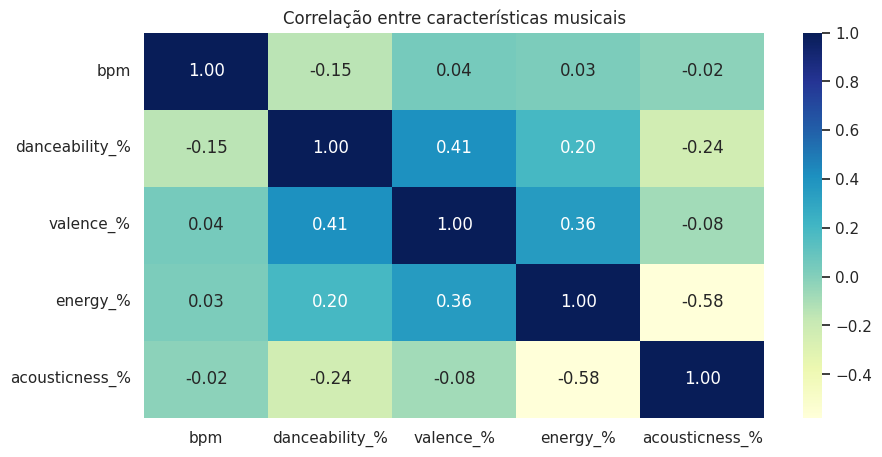

In [ ]:
cols_musicais = ['bpm','danceability_%', 'valence_%', 'energy_%', 'acousticness_%']
sns.heatmap(df[cols_musicais].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlação entre características musicais")
plt.show()


##Insigts
- **track_name**: Dos 953 registros, temos 943 nomes únicos, mas é possível observar 10 músicas repetidas.
  - Ao analisar mais detalhadamente essas músicas, é possível perceber que se tratam de versões interpretadas por artistas diferentes ou de variações da mesma faixa produzidas pelo próprio artista, em tonalidades distintas.

- **artist(s)_name**: 645 artistas únicos em 953 músicas(média de cerca de 1,47 músicas por artista.)
  - Alguns artistas apresentam presença dominante nas playlists, o que pode indicar talvez uma fã base muito forte ou uma qualidade expecional na produção dos seus singles.

In [ ]:
df.describe(include=['object'])

,track_name,artist(s)_name,key,mode,cover_url,ref_anomes
count,953,953,953,953,953,953
unique,943,645,12,2,535,256
top,About Damn Time,Taylor Swift,C#,Major,Not Found,06-2022
freq,2,34,120,550,225,33


In [ ]:
# Músicas que aparecem mais de uma vez
duplicadas = df[df.duplicated(subset=['track_name'], keep=False)]

duplicadas.sort_values('track_name').head(20)


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url,released_date,ref_anomes,total_playlists
764,About Damn Time,Lizzo,1,2022,4,14,9021,0,7.238945e+08,242,49,272,21,24,109,A#,Minor,84,72,74,10,0,34,7,https://i.scdn.co/image/ab67616d0000b273b817e7...,2022-04-14,14-2022,9535
372,About Damn Time,Lizzo,1,2022,7,15,2332,2,7.238945e+08,0,0,25,0,0,109,A#,Minor,84,72,74,10,0,34,7,https://i.scdn.co/image/ab67616d0000b273b817e7...,2022-07-15,15-2022,2357
13,Daylight,David Kushner,1,2023,4,14,3528,98,3.875707e+08,80,156,182,24,9999,130,D,Minor,51,32,43,83,0,9,3,https://i.scdn.co/image/ab67616d0000b27395ca6a...,2023-04-14,14-2023,3790
831,Daylight,Harry Styles,1,2022,5,20,2775,0,2.908332e+08,21,11,40,0,0,146,Miss_verificar,Major,69,63,45,48,0,18,4,https://i.scdn.co/image/ab67616d0000b2732e8ed7...,2022-05-20,20-2022,2836
47,Die For You,The Weeknd,1,2016,11,24,2483,59,1.647990e+09,68,21,24,0,259,134,C#,Minor,59,51,52,9,0,15,7,https://i.scdn.co/image/ab67616d0000b273a04841...,2016-11-24,24-2016,2575
417,Die For You,Joji,1,2022,11,4,1703,0,2.463901e+08,38,45,36,16,0,148,G#,Major,47,15,52,38,13,29,5,https://i.scdn.co/image/ab67616d0000b273eaac2a...,2022-11-04,04-2022,1777
12,Flowers,Miley Cyrus,1,2023,1,12,12211,115,1.316856e+09,300,215,745,58,9999,118,Miss_verificar,Major,71,65,68,6,0,3,7,https://i.scdn.co/image/ab67616d0000b27358039b...,2023-01-12,12-2023,13256
825,Flowers,Lauren Spencer Smith,1,2021,8,9,801,0,1.848264e+08,42,9,24,1,1,138,D#,Major,70,31,44,84,0,9,39,https://i.scdn.co/image/ab67616d0000b273295d21...,2021-08-09,09-2021,867
466,Let It Snow! Let It Snow! Let It Snow!,"Frank Sinatra, B. Swanson Quartet",2,1950,1,1,10585,0,4.732483e+08,126,108,406,0,0,143,D,Major,60,86,32,88,0,34,6,https://i.scdn.co/image/ab67616d0000b273df1066...,1950-01-01,01-1950,11117
448,Let It Snow! Let It Snow! Let It Snow!,Dean Martin,1,1959,11,16,6512,0,4.463901e+08,88,1,277,0,0,134,C#,Major,45,72,24,91,0,18,4,https://i.scdn.co/image/ab67616d0000b273e359bd...,1959-11-16,16-1959,6877


## Datas com maior lançamento de HITS
- No ano de 2022 foi o ano com a maior quantidade de HITS historicos, com cerca de 77% das músicas mais tocadas lançandas neste periodo.
  - Uma reflexão do porque isso pode ter acontecido:
    - Explosão dos streamings, principalmente por decorrencia da pandemia da covid 19
    
## Artistas mais tocados
- Observamos que a Taylor sem sal, digo Taylor Swift foi a artista com maior número de faixas entre as mais tocadas
- Nota-se também que não há uma dominância clara de um único estilo musical. O conjunto de artistas e faixas analisadas apresenta diversidade de gêneros, abrangendo pop, hip hop, reggaeton, R&B e outros, o que evidencia o caráter eclético e globalizado do consumo musical na plataforma.




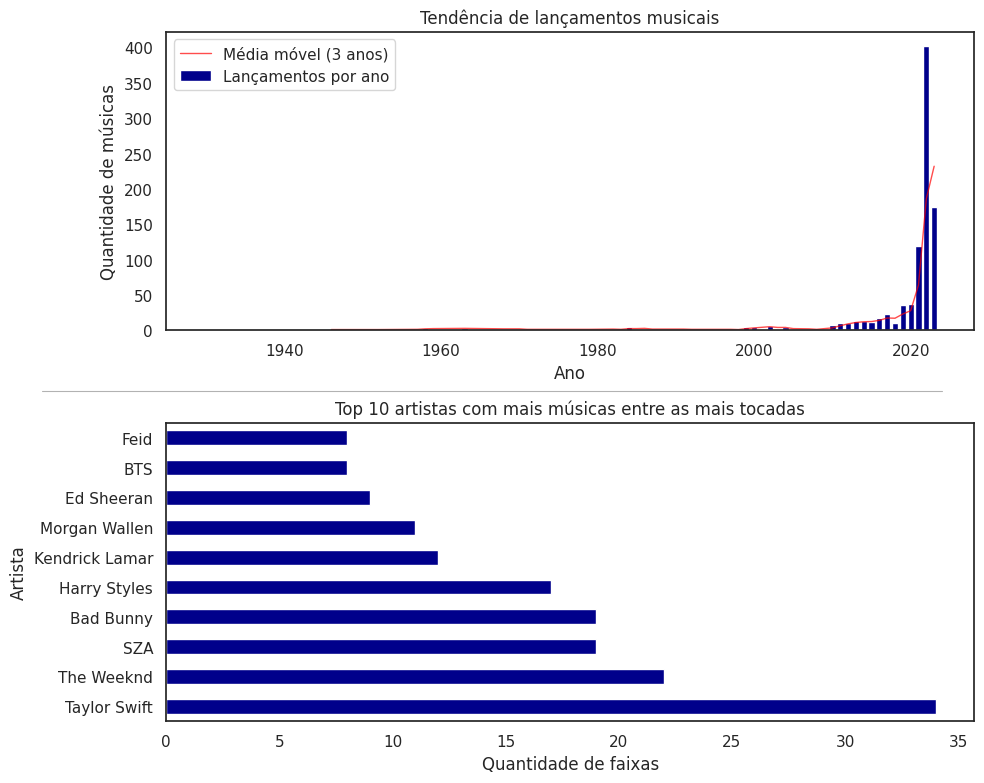

In [ ]:
# Cálculo da média móvel
rolling = counts_by_year.rolling(window=3).mean()

# Criação da figura
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# --- Gráfico 1 ---
axes[0].bar(counts_by_year.index, counts_by_year.values,
            color='darkblue', label='Lançamentos por ano')
axes[0].plot(rolling.index, rolling.values,
             color='red', linewidth=1, alpha=0.7, label='Média móvel (3 anos)')
axes[0].set_title('Tendência de lançamentos musicais')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Quantidade de músicas')
axes[0].legend()
fig.lines.append(plt.Line2D([0.05, 0.95], [0.5, 0.5],
                            color='gray', linewidth=0.8, alpha=0.6,
                            transform=fig.transFigure))

# --- Gráfico 2 ---
df['artist(s)_name'].value_counts().head(10).plot(
    kind='barh', color='darkblue', ax=axes[1])
axes[1].set_title('Top 10 artistas com mais músicas entre as mais tocadas')
axes[1].set_xlabel('Quantidade de faixas')
axes[1].set_ylabel('Artista')
plt.tight_layout()
plt.show()
